# Using LISA on a custom task: interpretable synthetic classification

This notebook is intentionally independent of **MASC-MEG**, audio embeddings, and the retrieval pipeline. It shows how to reuse LISA as a neural-signal encoder on a new task.

We build a synthetic three-class dataset in which every class has:

- a known oscillatory frequency: **6, 10, or 18 Hz**;
- a known smooth spatial topography over sensors;
- additional nuisance oscillations and sensor noise.

The example then:

1. passes `(signal, subject_index)` through the interpretable LISA front-end;
2. attaches a small, explicitly separate **classification head**;
3. trains the spatial filters and classifier;
4. visualizes the temporal frequency responses;
5. visualizes both spatial filters and covariance-derived spatial patterns.

The classification head is only an example. It is **not part of LISA** and can be replaced by a regression, retrieval, multilabel, or sequence-prediction head.

## 1. Setup

Run this notebook from either the repository root or the `notebooks/` directory. It uses only synthetic data and files already present in the repository. Install the project dependencies using the [Quickstart instructions](../README.md#quickstart) before running it.

The demo sets a single CPU thread because very small convolutional models can otherwise be slower on machines with many CPU cores. Remove that line for larger workloads.

In [1]:
from __future__ import annotations

import copy
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# Find the repository root from either ./ or ./notebooks.
repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if not (repo_root / "src" / "lisa").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks/ directory.")

src_dir = str(repo_root / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from lisa.model.nn_modules import LISA
from lisa.plots.branch_interpretation import calculate_spatial_patterns


def set_seed(seed: int = 7) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(7)
if not torch.cuda.is_available():
    torch.set_num_threads(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Define a synthetic sensor layout and known sources

The layout is a small scalp-like disc with 24 sensors. Each class is generated from a smooth Gaussian-shaped spatial source:

- class 0: left/anterior source at 6 Hz;
- class 1: posterior source at 10 Hz;
- class 2: right/anterior source at 18 Hz.

The exact source patterns are available here only because the data are synthetic. They let us check whether the learned LISA representation is interpretable.

In [2]:
sampling_rate = 100
n_times = 300
n_seconds = n_times / sampling_rate
class_frequencies = np.array([6.0, 10.0, 18.0], dtype=np.float32)
class_names = ["6 Hz / left", "10 Hz / posterior", "18 Hz / right"]

# Scalp-like 2D layout: an outer ring, an inner ring, and central sensors.
outer_angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)
inner_angles = np.linspace(0, 2 * np.pi, 8, endpoint=False) + np.pi / 8
sensor_xy = np.vstack(
    [
        np.c_[0.95 * np.cos(outer_angles), 0.95 * np.sin(outer_angles)],
        np.c_[0.55 * np.cos(inner_angles), 0.55 * np.sin(inner_angles)],
        [[0.0, 0.0], [0.25, 0.0], [-0.25, 0.0], [0.0, 0.25]],
    ]
).astype(np.float32)

# Approximate 3D hemisphere coordinates. They are required by the LISA constructor,
# although this minimal demo disables coordinate-constrained spatial attention.
radius_sq = np.sum(sensor_xy**2, axis=1)
sensor_z = np.sqrt(np.clip(1.0 - radius_sq, 0.0, 1.0))
sensor_xyz = np.c_[sensor_xy, sensor_z].astype(np.float32)
n_channels = sensor_xy.shape[0]

source_centers = np.array(
    [[-0.60, 0.25], [0.00, -0.55], [0.60, 0.25]], dtype=np.float32
)
source_width = 0.34
true_spatial_patterns = []
for center in source_centers:
    positive_blob = np.exp(
        -np.sum((sensor_xy - center) ** 2, axis=1) / (2 * source_width**2)
    )
    weak_surround = 0.18 * np.exp(
        -np.sum((sensor_xy + 0.4 * center) ** 2, axis=1) / (2 * 0.65**2)
    )
    pattern = positive_blob - weak_surround
    pattern /= np.linalg.norm(pattern)
    true_spatial_patterns.append(pattern)

true_spatial_patterns = np.stack(true_spatial_patterns).astype(np.float32)
print("sensor_xy:", sensor_xy.shape)
print("true_spatial_patterns:", true_spatial_patterns.shape)

sensor_xy: (24, 2)
true_spatial_patterns: (3, 24)


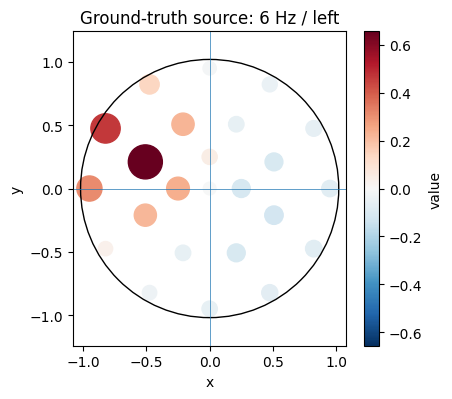

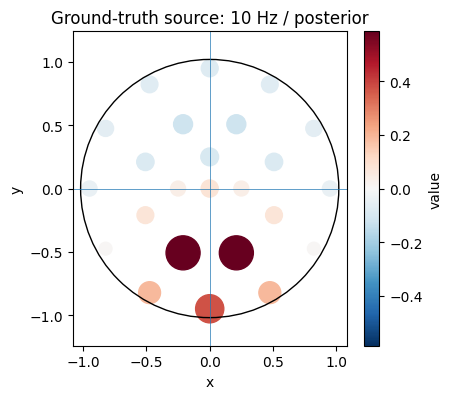

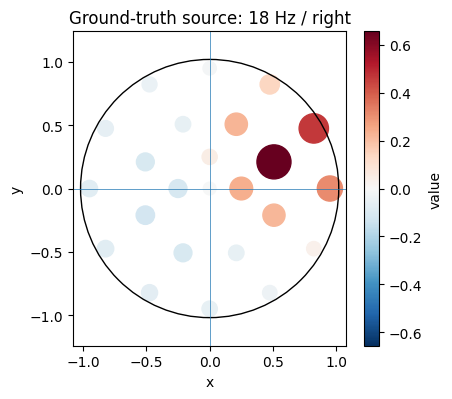

In [3]:
def plot_sensor_map(values: np.ndarray, title: str) -> None:
    """Plot one sensor-space vector on the synthetic layout."""
    values = np.asarray(values)
    scale = np.max(np.abs(values)) + 1e-12
    marker_sizes = 80 + 520 * np.abs(values) / scale

    plt.figure(figsize=(4.6, 4.1))
    points = plt.scatter(
        sensor_xy[:, 0],
        sensor_xy[:, 1],
        c=values,
        s=marker_sizes,
        cmap="RdBu_r",
        vmin=-scale,
        vmax=scale,
    )
    plt.colorbar(points, label="value")
    plt.gca().add_patch(plt.Circle((0, 0), 1.02, fill=False))
    plt.axhline(0, linewidth=0.5)
    plt.axvline(0, linewidth=0.5)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()


for class_index, class_name in enumerate(class_names):
    plot_sensor_map(
        true_spatial_patterns[class_index],
        f"Ground-truth source: {class_name}",
    )

## 3. Generate the classification dataset

Each sample contains one class-specific oscillatory source, two class-independent nuisance rhythms, channel-wise gain variability, and Gaussian sensor noise.

LISA expects each example as:

- `x`: `(channels, time)`;
- `subject_index`: a zero-based integer.

The data loader therefore returns `((x, subject_index), label)`. This demo uses one synthetic subject, so all subject indices are zero. For multisubject data, provide the real subject index and set `n_subjects` accordingly.

In [4]:
class SyntheticOscillationDataset(Dataset):
    def __init__(self, n_samples: int, seed: int):
        super().__init__()
        rng = np.random.default_rng(seed)
        time = np.arange(n_times, dtype=np.float32) / sampling_rate

        labels = rng.integers(0, len(class_names), size=n_samples, dtype=np.int64)

        # Nuisance patterns differ between train and validation datasets.
        nuisance_patterns = rng.normal(size=(2, n_channels)).astype(np.float32)
        nuisance_patterns /= np.linalg.norm(
            nuisance_patterns, axis=1, keepdims=True
        )

        examples = []
        for label in labels:
            phase = rng.uniform(0, 2 * np.pi)
            amplitude = rng.uniform(1.0, 1.5)
            slow_envelope = 0.8 + 0.2 * np.sin(
                2 * np.pi * 0.35 * time + rng.uniform(0, 2 * np.pi)
            )
            source = amplitude * slow_envelope * np.sin(
                2 * np.pi * class_frequencies[label] * time + phase
            )
            x = true_spatial_patterns[label, :, None] * source[None, :]

            for nuisance_frequency, nuisance_pattern in zip(
                [3.0, 24.0], nuisance_patterns
            ):
                nuisance = np.sin(
                    2 * np.pi * nuisance_frequency * time
                    + rng.uniform(0, 2 * np.pi)
                )
                x += 0.25 * nuisance_pattern[:, None] * nuisance[None, :]

            channel_gains = rng.lognormal(
                mean=0.0, sigma=0.08, size=(n_channels, 1)
            )
            x *= channel_gains
            x += rng.normal(scale=0.25, size=x.shape)

            # One global scale per sample preserves relative spatial amplitudes.
            x = x.astype(np.float32)
            x /= x.std() + 1e-6
            examples.append(x)

        self.x = torch.from_numpy(np.stack(examples))
        self.y = torch.from_numpy(labels)
        self.subject_index = torch.zeros(n_samples, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, index: int):
        return (self.x[index], self.subject_index[index]), self.y[index]


train_dataset = SyntheticOscillationDataset(n_samples=720, seed=1)
validation_dataset = SyntheticOscillationDataset(n_samples=240, seed=2)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=128, shuffle=False)

(x_batch, subject_batch), label_batch = next(iter(train_loader))
print("signals:", x_batch.shape)
print("subject indices:", subject_batch.shape, subject_batch.unique().tolist())
print("labels:", label_batch.shape, label_batch.unique().tolist())

signals: torch.Size([64, 24, 300])
subject indices: torch.Size([64]) [0]
labels: torch.Size([64]) [0, 1, 2]


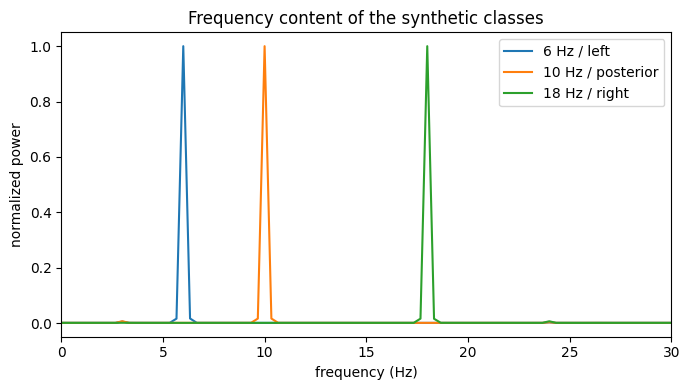

In [5]:
# Verify that the synthetic classes contain the intended frequencies.
frequency_grid = np.fft.rfftfreq(n_times, d=1 / sampling_rate)

plt.figure(figsize=(7.0, 4.0))
for class_index, class_name in enumerate(class_names):
    class_data = train_dataset.x[train_dataset.y == class_index].numpy()
    # Project through the known source pattern, then average the power spectra.
    projected = np.einsum(
        "c,nct->nt", true_spatial_patterns[class_index], class_data
    )
    power = np.mean(np.abs(np.fft.rfft(projected, axis=-1)) ** 2, axis=0)
    power /= power.max() + 1e-12
    plt.plot(frequency_grid, power, label=class_name)

plt.xlim(0, 30)
plt.xlabel("frequency (Hz)")
plt.ylabel("normalized power")
plt.title("Frequency content of the synthetic classes")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Instantiate LISA

This pedagogical configuration uses the interpretable front-end only:

1. a learned sensor-space unmixing matrix;
2. one depthwise temporal filter per branch.

Coordinate-constrained attention and the subject-specific layer are disabled so that the spatial transform is easy to inspect. They can be enabled on real data without changing the task-head interface.

The three temporal filters are initialized as FIR band-pass filters around the known synthetic frequencies. They are frozen here so the short demo cleanly separates two questions:

- do the temporal branches isolate the expected frequencies?;
- can the learned spatial filters recover the corresponding source topographies?

For a real task, choose one of three modes:

- `temporal_filter_bands=...`, `temporal_filter_freeze=True`: fixed filter bank;
- `temporal_filter_bands=...`, `temporal_filter_freeze=False`: FIR initialization followed by fine-tuning;
- `temporal_filter_bands=None`, `temporal_filter_freeze=False`: fully learned random initialization.

In [6]:
n_branches = 3

lisa = LISA(
    n_channels_input=n_channels,
    n_channels_attention=n_channels,
    n_channels_unmix=n_branches,
    use_spatial_attention=None,
    n_spatial_harmonics=4,
    coords_xyz=sensor_xyz,
    coords_xy_scaled=sensor_xy,
    spatial_dropout_number=0,
    spatial_dropout_radius=0.2,
    n_subjects=1,
    use_unmixing_layer=True,
    use_subject_layer=False,
    temporal_filter_type="conv",
    temporal_filter_bands=[(4.5, 7.5), (8.5, 11.5), (16.0, 20.0)],
    temporal_filter_freeze=True,
    temporal_filter_kernel_size=101,
    temporal_filter_padding_mode="reflect",
    tf_gated=False,
    tf_gate_per_channel=False,
    tf_gate_init_alpha=0.05,
    tf_gelu=False,
    # The full LISA object requires a tail configuration. This demo calls
    # forward_interpretable(), so the tail is not used by the classifier.
    n_temporal_module_blocks=0,
    n_channels_block=n_branches,
    n_features=12,
    head_pool="single_conv",
    head_stride=1,
    meg_sr=sampling_rate,
    seed=7,
)

spatial_filters, spatial_bias = lisa.extract_spatial_filters()
temporal_filters = lisa.extract_temporal_filters()
print("spatial filters:", spatial_filters.shape)
print("spatial bias:", None if spatial_bias is None else spatial_bias.shape)
print("temporal filters:", temporal_filters.shape)

spatial filters: torch.Size([1, 3, 24])
spatial bias: torch.Size([1, 3, 1])
temporal filters: torch.Size([3, 101])


## 5. Attach a task-specific classification head

The boundary is explicit in the code below:

- `forward_interpretable(...)` returns the LISA representation `z`;
- everything after that line is specific to this classification example.

The head computes log power for every LISA branch and applies a linear classifier. This head is appropriate because the synthetic labels are defined by oscillatory power. It is **not a required part of LISA**.

In [7]:
class LogPowerClassificationHead(nn.Module):
    """Example task head: branch log-power -> class logits."""

    def __init__(self, n_branches: int, n_classes: int):
        super().__init__()
        self.classifier = nn.Linear(n_branches, n_classes)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        log_power = torch.log(z.square().mean(dim=-1) + 1e-6)
        return self.classifier(log_power)


class LISAClassifier(nn.Module):
    def __init__(
        self, lisa_backbone: LISA, n_branches: int, n_classes: int
    ):
        super().__init__()
        self.lisa = lisa_backbone
        self.task_head = LogPowerClassificationHead(
            n_branches=n_branches, n_classes=n_classes
        )

    def forward(self, x: torch.Tensor, subject_index: torch.Tensor) -> torch.Tensor:
        # ======================= LISA =======================
        z = self.lisa.forward_interpretable((x, subject_index))
        # ==================== LISA ends here =================

        # Everything below is task-specific and replaceable.
        logits = self.task_head(z)
        return logits


model = LISAClassifier(
    lisa, n_branches=n_branches, n_classes=len(class_names)
).to(device)

with torch.no_grad():
    z = model.lisa.forward_interpretable(
        (x_batch[:4].to(device), subject_batch[:4].to(device))
    )
    logits = model(x_batch[:4].to(device), subject_batch[:4].to(device))

print("LISA representation z:", z.shape)
print("classification logits:", logits.shape)

LISA representation z: torch.Size([4, 3, 300])
classification logits: torch.Size([4, 3])


## 6. Train the spatial filters and classification head

Only parameters on the active path are optimized:

- the LISA spatial module;
- the external task head.

The temporal kernels are part of the spatial module but have `requires_grad=False` in this specific demo.

In [8]:
def evaluate(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for (x, subject_index), labels in loader:
            x = x.to(device)
            subject_index = subject_index.to(device)
            labels = labels.to(device)

            logits = model(x, subject_index)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.numel()
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.numel()

    return total_loss / total_examples, total_correct / total_examples


criterion = nn.CrossEntropyLoss()
active_parameters = [
    parameter
    for parameter in list(model.lisa.spatial_module.parameters())
    + list(model.task_head.parameters())
    if parameter.requires_grad
]
optimizer = torch.optim.AdamW(active_parameters, lr=3e-3, weight_decay=1e-3)

history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
best_state = None
best_validation_accuracy = -np.inf

for epoch in range(1, 13):
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_examples = 0

    for (x, subject_index), labels in train_loader:
        x = x.to(device)
        subject_index = subject_index.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x, subject_index)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * labels.numel()
        epoch_correct += (logits.argmax(dim=1) == labels).sum().item()
        epoch_examples += labels.numel()

    train_loss = epoch_loss / epoch_examples
    train_accuracy = epoch_correct / epoch_examples
    val_loss, val_accuracy = evaluate(model, validation_loader)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    if val_accuracy > best_validation_accuracy:
        best_validation_accuracy = val_accuracy
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"epoch {epoch:02d} | "
        f"train loss {train_loss:.3f}, acc {train_accuracy:.3f} | "
        f"val loss {val_loss:.3f}, acc {val_accuracy:.3f}"
    )

model.load_state_dict(best_state)
print(f"Best validation accuracy: {best_validation_accuracy:.3f}")

epoch 01 | train loss 1.900, acc 0.336 | val loss 1.245, acc 0.408
epoch 02 | train loss 0.983, acc 0.603 | val loss 0.688, acc 0.662
epoch 03 | train loss 0.577, acc 0.719 | val loss 0.425, acc 0.971
epoch 04 | train loss 0.371, acc 0.989 | val loss 0.303, acc 1.000
epoch 05 | train loss 0.274, acc 1.000 | val loss 0.237, acc 1.000
epoch 06 | train loss 0.222, acc 1.000 | val loss 0.201, acc 1.000
epoch 07 | train loss 0.191, acc 1.000 | val loss 0.176, acc 1.000
epoch 08 | train loss 0.168, acc 1.000 | val loss 0.155, acc 1.000
epoch 09 | train loss 0.149, acc 1.000 | val loss 0.139, acc 1.000
epoch 10 | train loss 0.133, acc 1.000 | val loss 0.125, acc 1.000
epoch 11 | train loss 0.119, acc 1.000 | val loss 0.112, acc 1.000
epoch 12 | train loss 0.108, acc 1.000 | val loss 0.101, acc 1.000
Best validation accuracy: 1.000


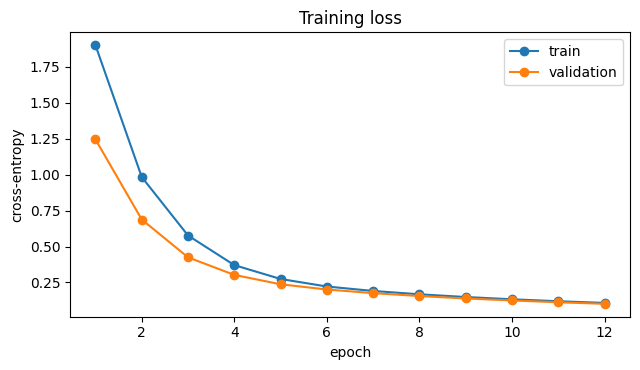

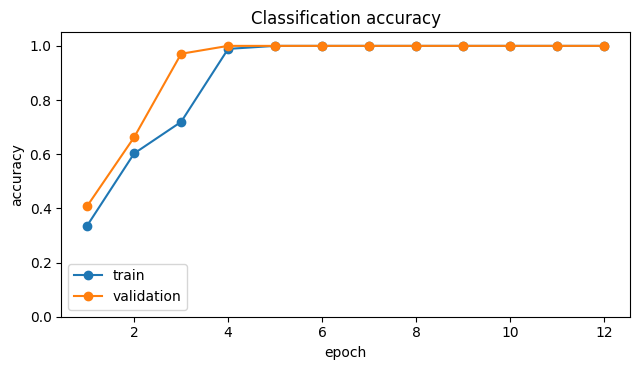

In [9]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6.5, 3.8))
plt.plot(epochs, history["train_loss"], marker="o", label="train")
plt.plot(epochs, history["val_loss"], marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("cross-entropy")
plt.title("Training loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 3.8))
plt.plot(epochs, history["train_accuracy"], marker="o", label="train")
plt.plot(epochs, history["val_accuracy"], marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.ylim(0, 1.05)
plt.title("Classification accuracy")
plt.legend()
plt.tight_layout()
plt.show()

[[76  0  0]
 [ 0 81  0]
 [ 0  0 83]]


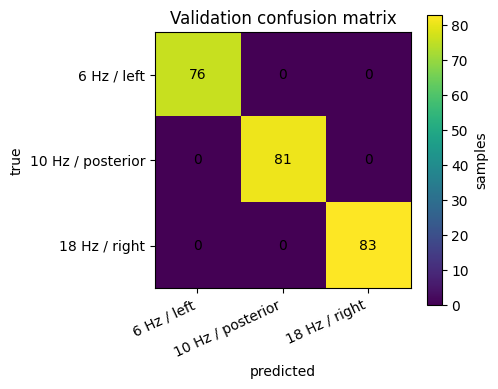

In [10]:
# Confusion matrix on the complete validation set.
model.eval()
all_labels = []
all_predictions = []
with torch.no_grad():
    for (x, subject_index), labels in validation_loader:
        logits = model(x.to(device), subject_index.to(device))
        all_labels.append(labels.numpy())
        all_predictions.append(logits.argmax(dim=1).cpu().numpy())

all_labels = np.concatenate(all_labels)
all_predictions = np.concatenate(all_predictions)
confusion = np.zeros((len(class_names), len(class_names)), dtype=int)
for true_label, predicted_label in zip(all_labels, all_predictions):
    confusion[true_label, predicted_label] += 1

print(confusion)

plt.figure(figsize=(5.0, 4.2))
image = plt.imshow(confusion)
plt.colorbar(image, label="samples")
plt.xticks(range(len(class_names)), class_names, rotation=25, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("Validation confusion matrix")
for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        plt.text(column, row, str(confusion[row, column]), ha="center", va="center")
plt.tight_layout()
plt.show()

## 7. Inspect the temporal filters

`extract_temporal_filters()` returns one depthwise kernel per interpretable branch with shape `(branches, kernel_size)`.

For a PyTorch `Conv1d`, the kernel is applied as cross-correlation rather than mathematical convolution. Reversing the kernel changes phase but not the magnitude spectrum, so the FFT magnitude below is the relevant quantity for identifying the selected frequency band.

branch 0: peak at 5.98 Hz
branch 1: peak at 9.99 Hz
branch 2: peak at 17.99 Hz


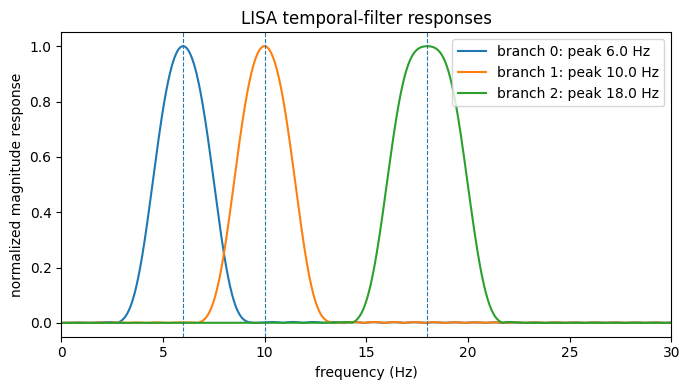

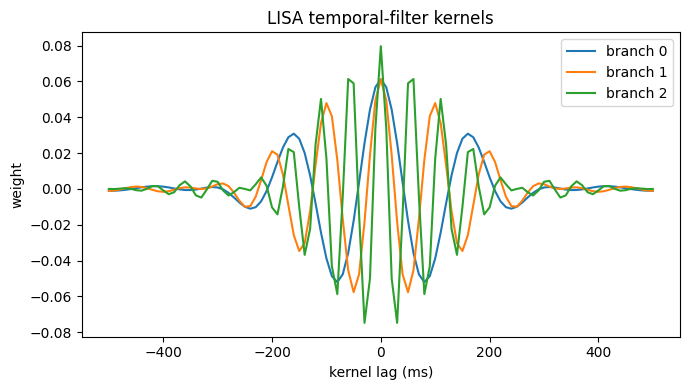

In [11]:
temporal_filters = model.lisa.extract_temporal_filters().numpy()
fft_size = 4096
filter_frequency_grid = np.fft.rfftfreq(fft_size, d=1 / sampling_rate)
filter_response = np.abs(
    np.fft.rfft(
        temporal_filters - temporal_filters.mean(axis=1, keepdims=True),
        n=fft_size,
        axis=1,
    )
)
filter_response /= filter_response.max(axis=1, keepdims=True) + 1e-12
peak_frequencies = filter_frequency_grid[np.argmax(filter_response, axis=1)]

for branch, peak in enumerate(peak_frequencies):
    print(f"branch {branch}: peak at {peak:.2f} Hz")

plt.figure(figsize=(7.0, 4.0))
for branch in range(n_branches):
    plt.plot(
        filter_frequency_grid,
        filter_response[branch],
        label=f"branch {branch}: peak {peak_frequencies[branch]:.1f} Hz",
    )
for frequency in class_frequencies:
    plt.axvline(frequency, linestyle="--", linewidth=0.8)
plt.xlim(0, 30)
plt.xlabel("frequency (Hz)")
plt.ylabel("normalized magnitude response")
plt.title("LISA temporal-filter responses")
plt.legend()
plt.tight_layout()
plt.show()

kernel_time_ms = (
    np.arange(temporal_filters.shape[1])
    - (temporal_filters.shape[1] - 1) / 2
) / sampling_rate * 1000

plt.figure(figsize=(7.0, 4.0))
for branch in range(n_branches):
    plt.plot(kernel_time_ms, temporal_filters[branch], label=f"branch {branch}")
plt.xlabel("kernel lag (ms)")
plt.ylabel("weight")
plt.title("LISA temporal-filter kernels")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Inspect spatial filters and spatial patterns

`extract_spatial_filters()` returns the complete sensor-to-branch linear transform after composing all active spatial stages. Its first dimension is subject index:

```text
(subjects, branches, sensors)
```

A **spatial filter** is a discriminative weighting used to extract a component. It does not necessarily look like the source topography that generated the data.

For source-style interpretation, covariance-derived **spatial patterns** are often more appropriate. The repository helper `calculate_spatial_patterns()` temporally filters the data branch by branch, estimates sensor covariance, and maps each discriminative filter back to an activation pattern.

Filter and pattern signs are arbitrary: multiplying a spatial filter and its corresponding downstream representation by `-1` leaves the model functionally equivalent. We therefore sign-align maps to the known synthetic sources before plotting.

In [12]:
spatial_filters, _ = model.lisa.extract_spatial_filters()
spatial_filters = spatial_filters.numpy()[0]  # synthetic subject 0

# Concatenate validation epochs to estimate a stable sensor covariance.
validation_meg = (
    validation_dataset.x.numpy()
    .transpose(1, 0, 2)
    .reshape(n_channels, -1)
)
spatial_patterns = calculate_spatial_patterns(
    meg=validation_meg,
    spatial_filters_weight=model.lisa.extract_spatial_filters()[0].numpy(),
    temporal_filters=model.lisa.extract_temporal_filters().numpy(),
    sub=1,  # this plotting helper uses one-based subject numbering
    filtfilt=False,
)

filter_correlations = np.array(
    [
        np.corrcoef(spatial_filters[branch], true_spatial_patterns[branch])[0, 1]
        for branch in range(n_branches)
    ]
)
pattern_correlations = np.array(
    [
        np.corrcoef(spatial_patterns[branch], true_spatial_patterns[branch])[0, 1]
        for branch in range(n_branches)
    ]
)

print("absolute filter/source correlations:", np.abs(filter_correlations).round(3))
print("absolute pattern/source correlations:", np.abs(pattern_correlations).round(3))

absolute filter/source correlations: [0.504 0.525 0.71 ]
absolute pattern/source correlations: [0.999 0.999 1.   ]


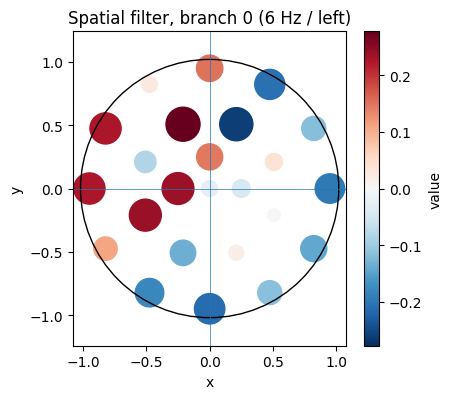

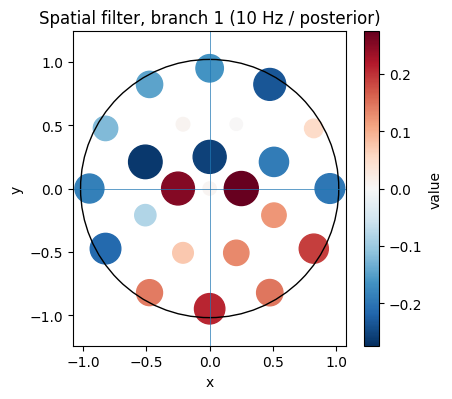

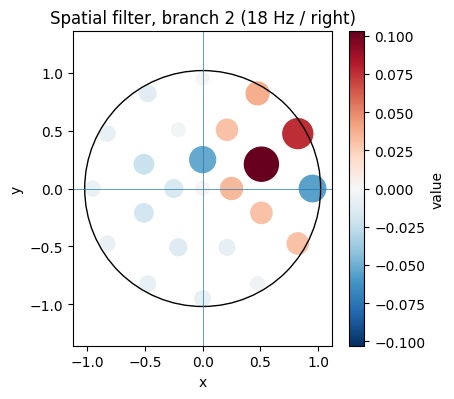

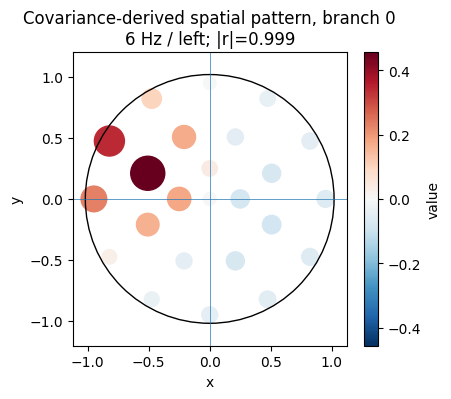

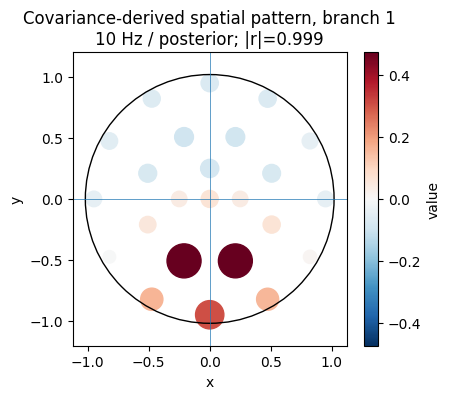

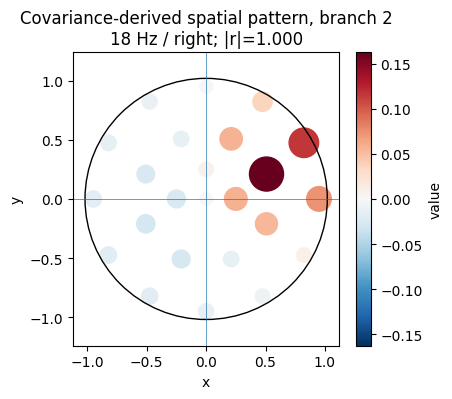

In [13]:
for branch, class_name in enumerate(class_names):
    filter_sign = 1.0 if filter_correlations[branch] >= 0 else -1.0
    plot_sensor_map(
        filter_sign * spatial_filters[branch],
        f"Spatial filter, branch {branch} ({class_name})",
    )

for branch, class_name in enumerate(class_names):
    pattern_sign = 1.0 if pattern_correlations[branch] >= 0 else -1.0
    plot_sensor_map(
        pattern_sign * spatial_patterns[branch],
        (
            f"Covariance-derived spatial pattern, branch {branch}\n"
            f"{class_name}; |r|={abs(pattern_correlations[branch]):.3f}"
        ),
    )

## 9. Using the full LISA encoder instead

This demo attaches the task head directly to the interpretable representation `z`. That is useful when branch-wise spatial and spectral power is the intended representation.

For a more expressive model, use the complete LISA tail and attach the task head to its final embedding:

```python
class FullLISAClassifier(nn.Module):
    def __init__(self, lisa: LISA, embedding_dim: int, n_classes: int):
        super().__init__()
        self.lisa = lisa
        self.task_head = nn.Linear(embedding_dim, n_classes)

    def forward(self, x, subject_index):
        z, embedding = self.lisa((x, subject_index))
        # LISA ends here. embedding has shape (batch, features, time).
        pooled_embedding = embedding.mean(dim=-1)
        return self.task_head(pooled_embedding)
```

In that case, set `n_temporal_module_blocks > 0` if you want the dilated convolutional tail used by the paper model.

## 10. Replace the example head for another task

The LISA interface does not assume retrieval or classification.

### Regression

Pool `z` or the final embedding and predict continuous targets:

```python
self.task_head = nn.Linear(embedding_dim, n_targets)
loss = nn.MSELoss()(prediction, target)
```

### Multilabel classification

Return one logit per label and use binary cross-entropy:

```python
self.task_head = nn.Linear(embedding_dim, n_labels)
loss = nn.BCEWithLogitsLoss()(logits, targets)
```

### Retrieval or contrastive learning

Keep the LISA embedding as one side of a shared embedding space and compare it with an embedding from another modality using cosine similarity or a contrastive loss. The repository training pipeline is one example, but it is not required by the architecture.

### Sequence prediction or segmentation

Do not pool over time. Apply a temporal prediction head to `(batch, features, time)` and align its output with time-resolved labels.

### Single- and multisubject data

- Single subject: set `n_subjects=1` and pass zeros.
- Multiple subjects: map subject identifiers to consecutive zero-based indices and pass the corresponding index for every sample.
- Unseen-subject inference requires a deliberate adaptation strategy; the subject-specific layer cannot index an identifier that was absent during construction.

## 11. Practical adaptation checklist

1. Arrange neural data as `(examples, channels, time)`.
2. Provide sensor coordinates if using 2D or 3D spatial attention.
3. Choose the number of interpretable branches with `n_channels_unmix`.
4. Decide whether temporal filters are fixed, initialized and fine-tuned, or learned from scratch.
5. Choose whether the task head consumes:
   - the interpretable representation from `forward_interpretable()`; or
   - the full embedding returned by `forward()`.
6. Keep the task head outside LISA so the architectural boundary remains explicit.
7. Use `extract_spatial_filters()` and `extract_temporal_filters()` for inspection.
8. Prefer covariance-derived spatial patterns over raw filters when interpreting source-like topographies.
9. Validate interpretation on held-out data and remember that spatial-filter sign is arbitrary.

For the exact architecture and all constructor/CLI options, see:

- [`documentation/ARCHITECTURE.md`](../documentation/ARCHITECTURE.md)
- [`documentation/HYPERPARAMETERS.md`](../documentation/HYPERPARAMETERS.md)